In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from google.colab import files

# 데이터 로드
uploaded = files.upload()
red_wine_data = pd.read_csv('winequality-red.csv', sep=";")


Saving winequality-red.csv to winequality-red.csv


In [5]:
# 데이터 확인
red_wine_data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


원본(red_wine_data) MLR

In [6]:
import statsmodels.api as sm
X = red_wine_data.drop('quality', axis=1)
y = red_wine_data['quality']
X = sm.add_constant(X)
model = sm.OLS(y,X)
results = model.fit()
print(results.params)
print(results.summary())

const                   21.965208
fixed acidity            0.024991
volatile acidity        -1.083590
citric acid             -0.182564
residual sugar           0.016331
chlorides               -1.874225
free sulfur dioxide      0.004361
total sulfur dioxide    -0.003265
density                -17.881164
pH                      -0.413653
sulphates                0.916334
alcohol                  0.276198
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.361
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     81.35
Date:                Tue, 14 Nov 2023   Prob (F-statistic):          1.79e-145
Time:                        14:02:16   Log-Likelihood:                -1569.1
No. Observations:                1599   AIC:                             3162.
Df Residuals:           

In [11]:
model = sm.OLS(y,X).fit()
residuals = model.resid
np.mean(round(residuals))
np.var(residuals)

0.416767167221408

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

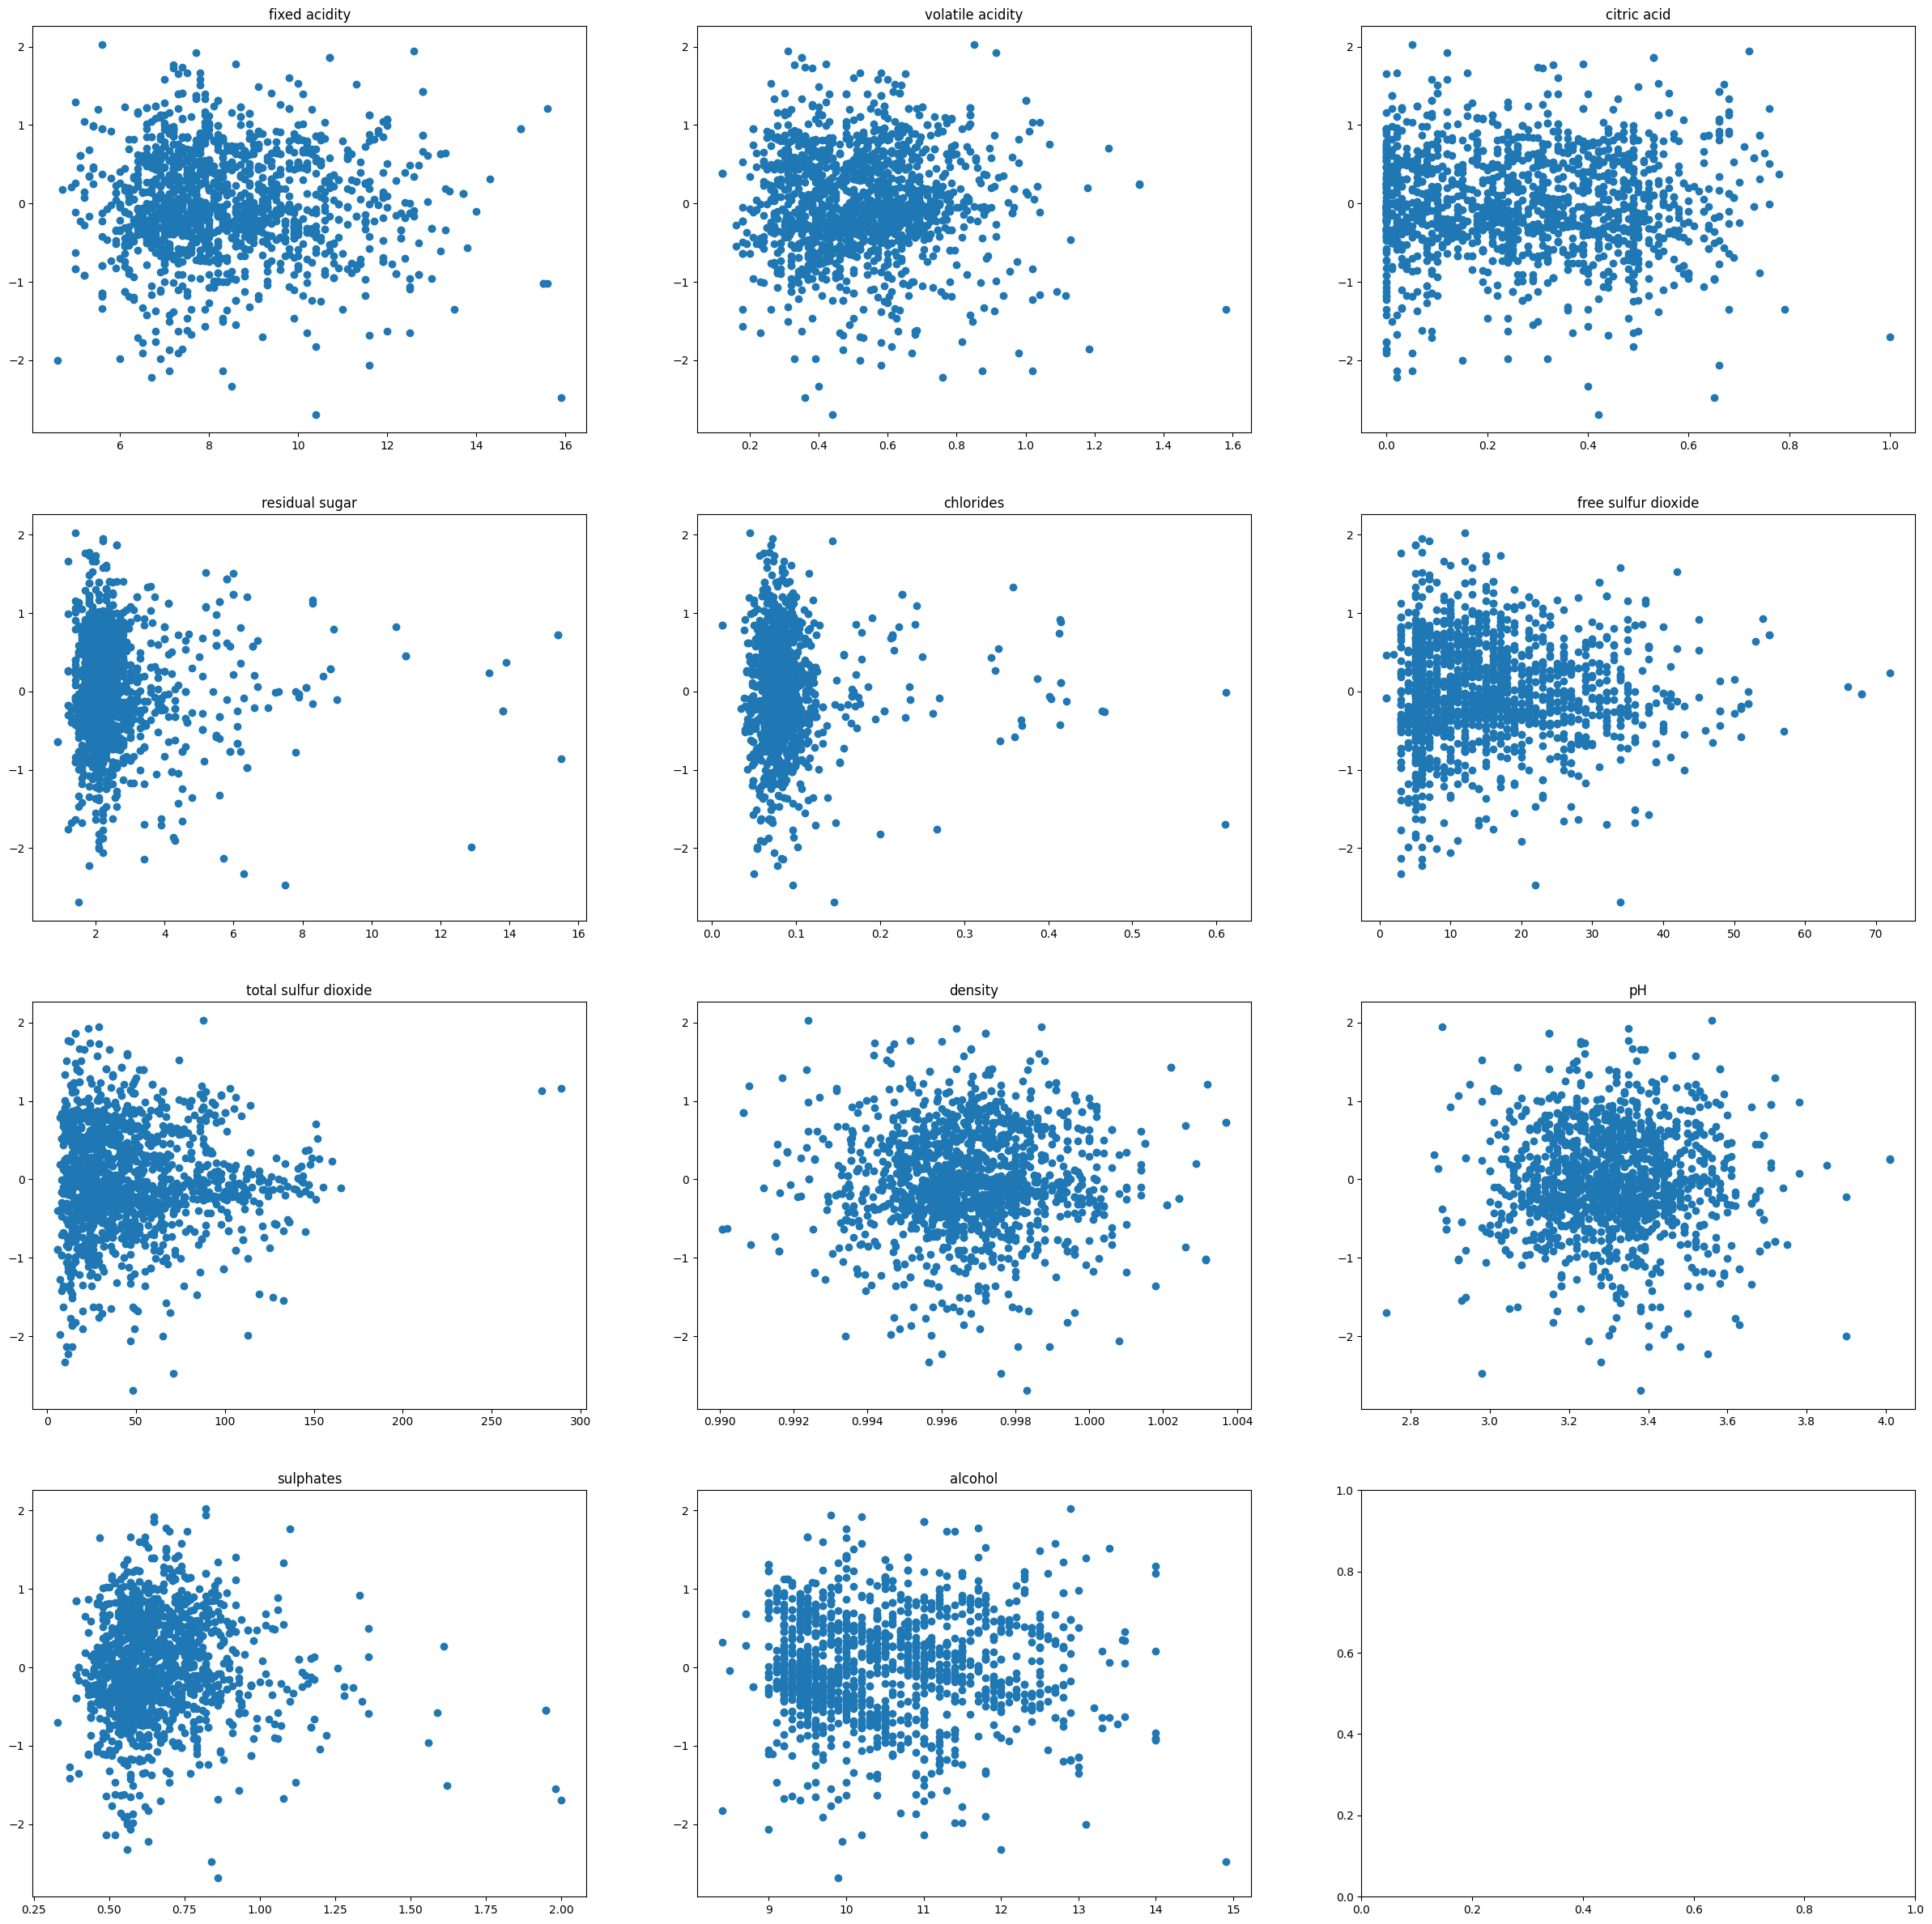

In [8]:
fig, axes = plt.subplots(4, 3, figsize=(30, 30))
axes = axes.ravel()

for i, col in enumerate(X.columns[1:]):
  axes[i].scatter(X[col], residuals)
  axes[i].set_title(f'{col}')

plt.savefig('scatter_plots.png')
from google.colab import files
files.download('scatter_plots.png')
plt.show()

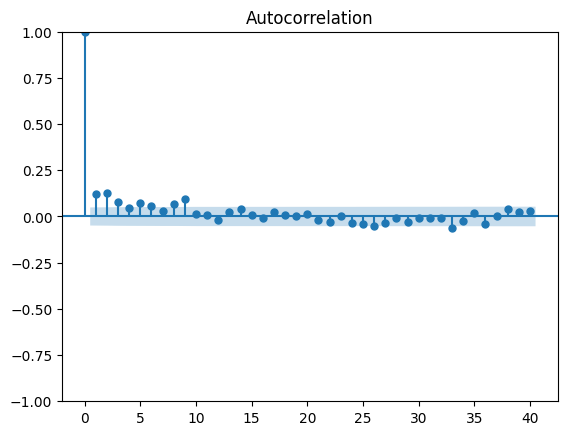

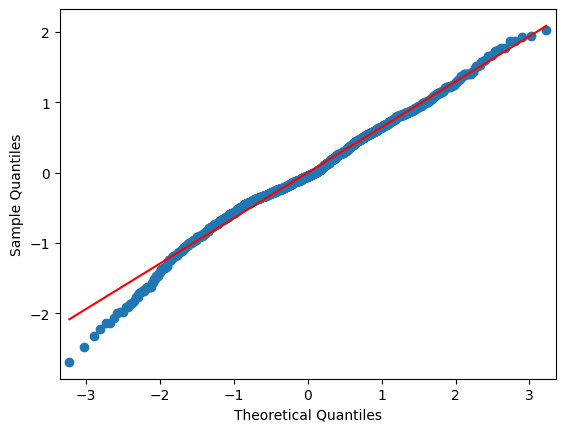

In [9]:
sm.graphics.tsa.plot_acf(residuals, lags=40)  # 자기상관도 플롯
sm.qqplot(residuals, line='s')  # QQ 플롯

plt.show()